# LoRA 角色扮演微调 — Phi-3.5-mini-instruct + QLoRA

**硬件:** RTX 4060 Laptop 8GB VRAM  
**模型:** Phi-3.5-mini-instruct (3.8B)  
**数据集:** amaydle/npc-dialogue (~1.7K 条 NPC 对话)  
**方法:** QLoRA (4-bit NF4 量化 + LoRA)

与 Qwen 版的区别:
- Phi-3.5 用 `<|system|>/<|user|>/<|assistant|><|end|>` 格式
- LoRA target 模块为 `qkv_proj, o_proj, gate_up_proj, down_proj`
- npc-dialogue 是单轮 Q&A 数据集（Biography → Query → Response）

## 1. 环境检查

虚拟环境 `.venv` 已预先创建（PyTorch cu124 + 全部依赖）。

> 如果还未切换 kernel：右上角选择 `Python (roleplay-lora)`，然后运行本 cell。

In [6]:
import sys, os
from pathlib import Path
import torch

# -- 必须在任何 HuggingFace 相关导入之前设置镜像 --
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
print("HF 镜像: hf-mirror.com")

# -- 确认在正确的虚拟环境中 --
VENV_DIR = Path.cwd() / ".venv"
in_venv = str(VENV_DIR) in sys.prefix or str(VENV_DIR) in sys.executable
print(f"Python: {sys.executable}")
if not in_venv:
    print("⚠️  当前不在 .venv 中，请切换到 Python (roleplay-lora) kernel 后重试")
else:
    print("✅ 虚拟环境: OK")

# -- 检查 GPU --
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}  |  cuDNN: {torch.version.cuda}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  |  显存: {props.total_memory / (1024**3):.1f} GB")
    assert props.total_memory / (1024**3) >= 7.5, f"显存不足"
else:
    raise RuntimeError("CUDA 不可用，请确认已切换到 Python (roleplay-lora) kernel")

HF 镜像: hf-mirror.com
Python: /home/arccc/Roleplay/.venv/bin/python
✅ 虚拟环境: OK
PyTorch: 2.6.0+cu124  |  CUDA: True  |  cuDNN: 12.4
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  |  显存: 8.0 GB


## 2. 配置参数

In [7]:
import os
from datetime import datetime

# ========== 模型配置 ==========
MODEL_NAME = "microsoft/Phi-3.5-mini-instruct"  # 3.8B 参数

# ========== 数据集配置 ==========
DATASET_NAME = "amaydle/npc-dialogue"             # ~1.7K 条 NPC 对话
MAX_SEQ_LENGTH = 512

# ========== QLoRA 配置 ==========
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
# Phi-3.5 的 linear 层命名: qkv_proj (合并QKV), o_proj, gate_up_proj, down_proj
LORA_TARGET_MODULES = [
    "qkv_proj", "o_proj",
    "gate_up_proj", "down_proj",
]

# ========== 训练配置 ==========
OUTPUT_DIR = "./roleplay-lora-extra"
BATCH_SIZE = 1
GRADIENT_ACCUMULATION = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 3
WARMUP_STEPS = 50
LOGGING_STEPS = 5
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 2

# ========== 日志 ==========
LOG_DIR = os.path.join(OUTPUT_DIR, "logs", datetime.now().strftime("%Y%m%d-%H%M%S"))

print(f"输出目录: {OUTPUT_DIR}")
print(f"日志目录: {LOG_DIR}")
print(f"显存估算: Phi-3.5-mini ~2.5GB(4-bit) + LoRA + 激活值 ≈ 5-6GB | 安全 ✓")

输出目录: ./roleplay-lora-extra
日志目录: ./roleplay-lora-extra/logs/20260610-233857
显存估算: Phi-3.5-mini ~2.5GB(4-bit) + LoRA + 激活值 ≈ 5-6GB | 安全 ✓


## 3. 加载并格式化数据集

amaydle/npc-dialogue 字段: `Name`, `Biography`, `Query`, `Response`, `Emotion`。
每一行是一条单轮 NPC 对话，需要用 Phi-3.5 的 chat template 格式化。

In [8]:
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Phi-3.5 用 <|endoftext|> 作 EOS/PAD

print(f"Tokenizer vocab: {len(tokenizer)}")
print(f"Chat template 前 200 字符: {tokenizer.chat_template[:200] if tokenizer.chat_template else 'None'}...")

# 加载原始数据集（自带 train/test 拆分）
raw_dataset = load_dataset(DATASET_NAME)
print(f"数据集: {raw_dataset}")
print(f"字段: {raw_dataset['train'].column_names}")
print(f"\n--- 样本预览 (train[0]) ---")
print(f"  Name: {raw_dataset['train'][0]['Name']}")
print(f"  Biography: {raw_dataset['train'][0]['Biography'][:150]}...")
print(f"  Query: {raw_dataset['train'][0]['Query']}")
print(f"  Response: {raw_dataset['train'][0]['Response']}")
print(f"  Emotion: {raw_dataset['train'][0]['Emotion']}")

Tokenizer vocab: 32011
Chat template 前 200 字符: {% for message in messages %}{% if message['role'] == 'system' and message['content'] %}{{'<|system|>
' + message['content'] + '<|end|>
'}}{% elif message['role'] == 'user' %}{{'<|user|>
' + message['...
数据集: DatasetDict({
    train: Dataset({
        features: ['Name', 'Biography', 'Query', 'Response', 'Emotion'],
        num_rows: 1723
    })
    test: Dataset({
        features: ['Name', 'Biography', 'Query', 'Response', 'Emotion'],
        num_rows: 192
    })
})
字段: ['Name', 'Biography', 'Query', 'Response', 'Emotion']

--- 样本预览 (train[0]) ---
  Name: Bikram
  Biography: Bikram is a rough and tough smuggler from the streets of Calcutta, India....
  Query: What is your opinion on friendship?
  Response: Friendship is a bond stronger than blood.
  Emotion: Loyalty


In [9]:
def format_conversation(example):
    """
    npc-dialogue 是单轮对话:
      - system: Biography (NPC 角色描述)
      - user: Query (玩家提问)
      - assistant: Response (NPC 回复)
    
    使用 Phi-3.5 的 chat template 转为训练文本。
    Phi-3.5 格式: <|system|>...<|end|><|user|>...<|end|><|assistant|>...<|end|>
    """
    messages = [
        {"role": "system", "content": example["Biography"]},
        {"role": "user", "content": example["Query"]},
        {"role": "assistant", "content": example["Response"]},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": text}


print("正在格式化训练集...")
formatted_train = raw_dataset["train"].map(
    format_conversation, remove_columns=raw_dataset["train"].column_names
)

print("正在格式化测试集...")
formatted_test = raw_dataset["test"].map(
    format_conversation, remove_columns=raw_dataset["test"].column_names
)

sample = formatted_train[0]["text"]
print(f"train: {len(formatted_train)} 条  |  test: {len(formatted_test)} 条")
print(f"\n--- Phi-3.5 格式化样本 ---")
print(sample[:400])

正在格式化训练集...
正在格式化测试集...
train: 1723 条  |  test: 192 条

--- Phi-3.5 格式化样本 ---
<|system|>
Bikram is a rough and tough smuggler from the streets of Calcutta, India.<|end|>
<|user|>
What is your opinion on friendship?<|end|>
<|assistant|>
Friendship is a bond stronger than blood.<|end|>
<|endoftext|>


In [10]:
train_dataset = formatted_train
eval_dataset = formatted_test

print(f"训练集: {len(train_dataset)} 条  |  验证集: {len(eval_dataset)} 条")
print(f"等效 batch size: {BATCH_SIZE} × {GRADIENT_ACCUMULATION} = {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"预计步数/epoch: ~{len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION)}")

训练集: 1723 条  |  验证集: 192 条
等效 batch size: 1 × 8 = 8
预计步数/epoch: ~215


## 4. 加载模型 (4-bit QLoRA)

Phi-3.5-mini-instruct ~3.8B 参数，4-bit 后约 2.5GB。

In [11]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"正在加载模型: {MODEL_NAME}")
print("首次加载会从 HuggingFace 下载 ~7.6GB 权重（压缩后 ~3.8GB），请耐心等待...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)

model.config.use_cache = False

mem_used = torch.cuda.memory_allocated() / (1024**3)
print(f"显存使用: {mem_used:.2f} GB")
print(f"总参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")

正在加载模型: microsoft/Phi-3.5-mini-instruct
首次加载会从 HuggingFace 下载 ~7.6GB 权重（压缩后 ~3.8GB），请耐心等待...


`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.75s/it]


显存使用: 2.11 GB
总参数量: 2009M


## 5. 配置 LoRA

Phi-3.5 使用合并的 QKV 投影 (`qkv_proj`)，与 Qwen 的分裂投影不同。

In [12]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"可训练参数: {trainable / 1e6:.2f}M / {total / 1e6:.0f}M ({100 * trainable / total:.2f}%)")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}, modules={LORA_TARGET_MODULES}")

可训练参数: 12.58M / 2022M (0.62%)
LoRA: r=8, alpha=16, modules=['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj']


## 6. 训练 (支持断点续传)

In [13]:
from transformers import TrainingArguments
from trl import SFTTrainer
import os

# ---- 检查是否有 checkpoint 可恢复 ----
resume_from_checkpoint = None
if os.path.exists(OUTPUT_DIR):
    checkpoints = [
        d for d in os.listdir(OUTPUT_DIR)
        if d.startswith("checkpoint-") and os.path.isdir(os.path.join(OUTPUT_DIR, d))
    ]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[1]))
        resume_from_checkpoint = os.path.join(OUTPUT_DIR, checkpoints[-1])
        print(f"🔁 发现 checkpoint: {resume_from_checkpoint}")
    else:
        print("未发现 checkpoint，开始全新训练")
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("未发现 checkpoint，开始全新训练")

# ---- 训练参数 ----
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    logging_steps=LOGGING_STEPS,
    logging_dir=LOG_DIR,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    eval_strategy="steps",
    eval_steps=SAVE_STEPS,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_8bit",
    report_to="tensorboard",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    dataloader_num_workers=0,
    seed=42,
)

print(f"TensorBoard 日志: {LOG_DIR}")
print(f"运行 `tensorboard --logdir {LOG_DIR}` 可实时查看")

未发现 checkpoint，开始全新训练
TensorBoard 日志: ./roleplay-lora-extra/logs/20260610-233857
运行 `tensorboard --logdir ./roleplay-lora-extra/logs/20260610-233857` 可实时查看


In [14]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    formatting_func=lambda x: x["text"],
)

if resume_from_checkpoint:
    print(f"从 {resume_from_checkpoint} 恢复训练...")
else:
    print("开始全新训练...")

# ========== 开始训练 ==========
trainer.train(resume_from_checkpoint=resume_from_checkpoint)

print("\n✅ 训练完成！")

开始全新训练...


You are not running the flash-attention implementation, expect numerical differences.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.617600,0.648508,0.621485,83481.000000,0.825345
200,0.417900,0.403402,0.428564,165981.000000,0.891963
300,0.334100,0.393053,0.358917,247681.000000,0.894090
400,0.344100,0.371342,0.337198,330486.000000,0.899129
500,0.246400,0.386307,0.280639,413718.000000,0.897180
600,0.250200,0.384054,0.273195,495578.000000,0.899622



✅ 训练完成！


## 7. 保存最终模型

In [15]:
final_model_path = os.path.join(OUTPUT_DIR, "final-lora-adapter")
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)

adapter_size = sum(f.stat().st_size for f in os.scandir(final_model_path) if f.is_file()) / 1e6
print(f"LoRA adapter 已保存到: {final_model_path}")
print(f"Adapter 大小: {adapter_size:.1f} MB")

del trainer
torch.cuda.empty_cache()

LoRA adapter 已保存到: ./roleplay-lora-extra/final-lora-adapter
Adapter 大小: 54.0 MB


## 8. 可视化训练指标

读取日志: ./roleplay-lora-extra/logs/20260610-233857/events.out.tfevents.1781106013.LAPTOP-BUEB1633.1561.0


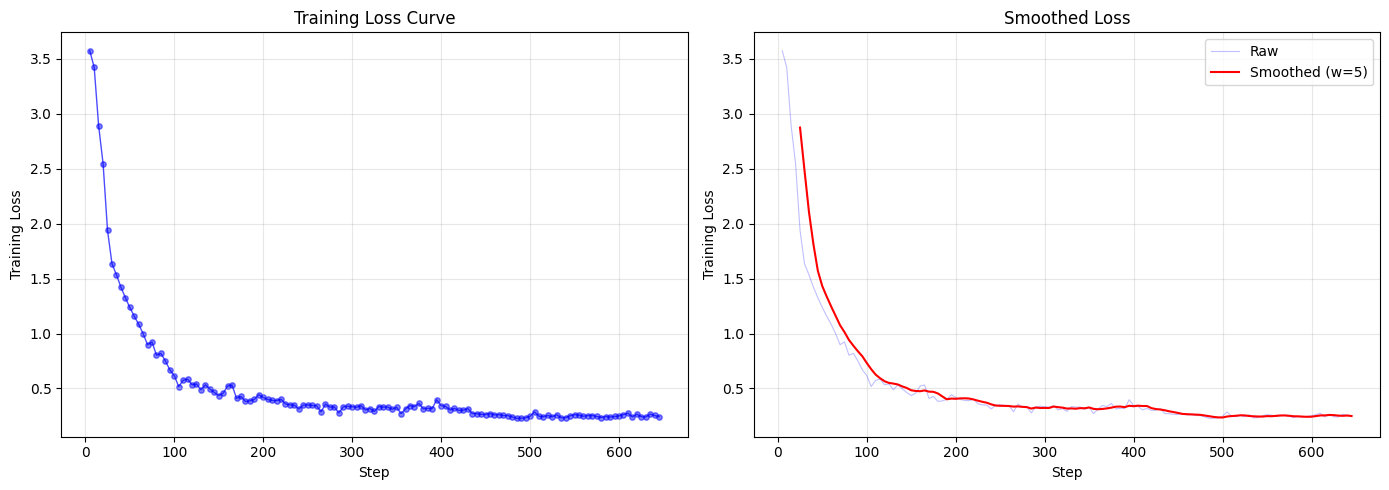

Loss 曲线已保存: ./roleplay-lora-extra/loss_curve.png
Loss: 3.5751 → 0.2433 (下降 3.3318)


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob

event_files = sorted(glob.glob(os.path.join(LOG_DIR, "**/events.out.tfevents.*"), recursive=True))
if not event_files:
    event_files = sorted(glob.glob(os.path.join(LOG_DIR, "events.out.tfevents.*")))

if not event_files:
    print("未找到 TensorBoard 日志，请确认训练已运行。")
else:
    event_file = event_files[0]
    print(f"读取日志: {event_file}")
    
    ea = EventAccumulator(event_file)
    ea.Reload()
    
    if "train/loss" not in ea.Tags()["scalars"]:
        print(f"可用 scalars: {ea.Tags()['scalars']}")
    else:
        train_loss = ea.Scalars("train/loss")
        steps = [s.step for s in train_loss]
        values = [s.value for s in train_loss]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(steps, values, "b-", alpha=0.7, linewidth=1)
        axes[0].scatter(steps, values, s=15, alpha=0.5, color="blue")
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Training Loss")
        axes[0].set_title("Training Loss Curve")
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(steps, values, "b-", alpha=0.25, linewidth=0.8, label="Raw")
        if len(values) >= 5:
            window = min(5, len(values))
            smoothed = np.convolve(values, np.ones(window)/window, mode="valid")
            axes[1].plot(steps[window-1:], smoothed, "r-", linewidth=1.5, label=f"Smoothed (w={window})")
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Training Loss")
        axes[1].set_title("Smoothed Loss")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Loss 曲线已保存: {OUTPUT_DIR}/loss_curve.png")
        print(f"Loss: {values[0]:.4f} → {values[-1]:.4f} (下降 {values[0]-values[-1]:.4f})")

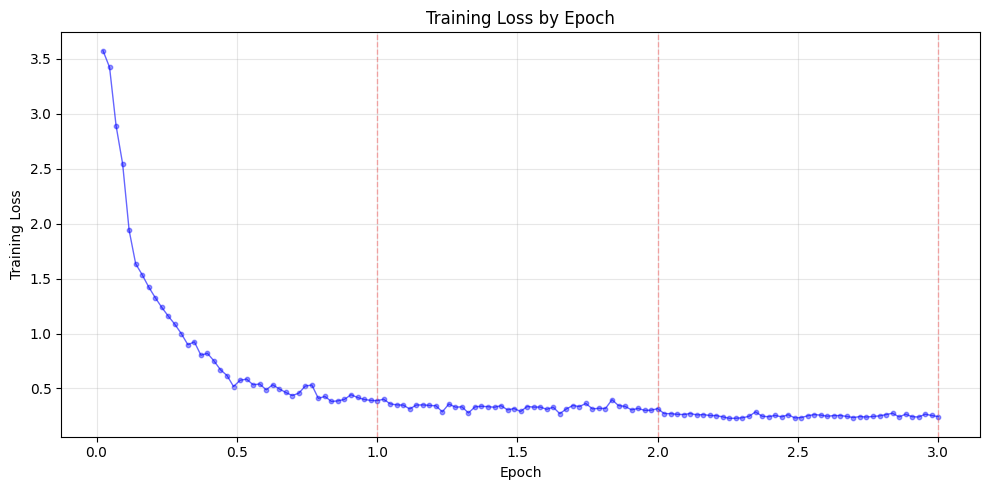

Epoch 曲线已保存: ./roleplay-lora-extra/loss_by_epoch.png


In [17]:
# per-epoch 可视化
if event_files and "train/loss" in ea.Tags()["scalars"]:
    steps_per_epoch = max(len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION), 1)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    epochs = [s / steps_per_epoch for s in steps]
    ax.plot(epochs, values, "b-", alpha=0.6, linewidth=1)
    ax.scatter(epochs, values, s=10, alpha=0.4, color="blue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss by Epoch")
    ax.grid(True, alpha=0.3)
    
    for ep in range(1, NUM_EPOCHS + 1):
        ax.axvline(x=ep, color="red", linestyle="--", alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_by_epoch.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Epoch 曲线已保存: {OUTPUT_DIR}/loss_by_epoch.png")

---

## 附录

### TensorBoard 实时监控

```bash
tensorboard --logdir ./roleplay-lora-extra/logs
```

### 断点续传

训练中断后，直接重新运行 **Section 6 的两个 cell** 即可自动从最新 checkpoint 恢复。

### Phi-3.5 vs Qwen 关键差异

| | Qwen2.5-1.5B | Phi-3.5-mini |
|---|---|---|
| 参数 | 1.5B | 3.8B |
| Chat 格式 | `<\|im_start\|>...<\|im_end\|>` | `<\|system\|>...<\|end\|>` |
| Attention | q/k/v/o_proj | qkv_proj, o_proj |
| MLP | gate/up/down_proj | gate_up_proj, down_proj |
| 数据集 | roleplay (5.7K) | npc-dialogue (1.7K) |
| 对话轮次 | 多轮 | 单轮 |
| 4-bit 显存 | ~1.5GB | ~2.5GB |